# Poison Frogs - Clean-Label Poisoning (Transfer Learning)

A projected feature-collision adaptation of Shafahi et al., *"Poison Frogs! Targeted Clean-Label Poisoning Attacks on Neural Networks"* (NeurIPS 2018), Section 3, on CIFAR-10 with a frozen ImageNet-pretrained ResNet-18 + a retrained linear head -- not a literal reproduction: different dataset, different (smaller) feature extractor, and a joint-Adam relaxation of the paper's Algorithm 1.

**Objective (a projected feature-collision variant of Eq. 1):**

```
poison = argmin_x  ||f(x) - f(target)||^2  +  beta * ||x - base||^2
```

Solved by Adam gradient descent with an L-infinity projection back to an epsilon-ball around the base image after each step. The poison is labeled as the **base** class - correctly, which is the "clean label" part - and simply added to the training set. A successful attack makes the classifier misclassify the unmodified target as the base class at test time.

Self-contained notebook: the attack itself (`craft_feature_collision*` below) is hand-written PyTorch autograd, no attack library. The pretrained weights, dataset split, and every RNG are pinned via `SEED` for reproducibility.

Crafts poisons for many target instances against one fixed base instance (paper Section 3.1 / Fig. 1b methodology) and reports an attack success rate, a confidence histogram, and the clean-vs-poisoned accuracy delta.


## Environment

Uses Kaggle's preinstalled torch/torchvision (already matched to its CUDA driver) instead of a pinned pip install. Reproducibility instead comes from pinning the weights enum, the dataset split, and every RNG via `SEED`.


In [1]:
# !pip install -q torch==2.5.1 torchvision==0.20.1 numpy==1.26.4  # optional exact repo pins; restart runtime after

import os, sys, time, json, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset as TorchTensorDataset
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
import torchvision
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA available: True


## Config

Attacks `NUM_TRIALS` different targets against one fixed base image (paper's one-shot-kill setup, Section 3.1).

`TRAIN_SAMPLES_PER_CLASS` is kept small on purpose. Paper Appendix D argues, for its binary dog-vs-fish setup, that the attack needs the linear head's fit to be underdetermined (fewer training points than trainable parameters). We extrapolate that to `N_tr <= feature_dim * num_classes = 512*10 = 5120` for this 10-class problem as a heuristic, not a proven bound -- what we did verify directly is the two endpoints: the full 5000/class split (`N_tr=50,000`, ~10x over that threshold) gave 0/50 successes, and shrinking below it is what got the attack working.

Each trial now trains a matched clean/poisoned head pair from the same seed (see the Full experiment cell), which roughly doubles head-training time. Runtime: roughly 15-20 minutes end to end on a Kaggle T4/P100 for the main experiment; the optional epsilon-sensitivity section at the end adds more.


In [2]:
SEED = 406

# Attack (projected feature-collision, adapted from Eq. 1)
TARGET_CLASS = 0   # airplane: the class the target instance truly belongs to
BASE_CLASS = 6     # frog: the class the poison is (correctly) labeled as
BASE_RANK = 0      # which frog instance from the TEST set (fixed across all trials, paper Fig. 1b style)
NUM_TRIALS = 50    # number of distinct target instances to attack
ATTACK_STEPS = 3000
ATTACK_LR = 0.01
ATTACK_BETA = 0.1
ATTACK_EPSILON = 0.06   # L-infinity budget in [0, 1] pixel units (~15/255)
LOG_EVERY = 200

# Victim training (frozen ResNet-18 features + retrained linear head)
# Keep N_tr = NUM_CLASSES * TRAIN_SAMPLES_PER_CLASS under feature_dim * NUM_CLASSES
# (512*10=5120) -- extrapolating paper Appendix D's (binary-case) argument that
# an underdetermined fit is what gives the attack any leverage at all. Not a
# proven bound for this 10-class case, but the full 5000/class split (10x over
# this threshold) measurably fails (0/50), and this smaller split works.
TRAIN_SAMPLES_PER_CLASS = 200   # N_tr = 2000
TEST_SAMPLES_PER_CLASS = 1000   # full test split, evaluation only
EPOCHS = 100     # paper: Adam, 100 epochs, near-zero training loss
BATCH_SIZE = 128
HEAD_LR = 0.01   # paper: Adam, lr=0.01
WEIGHT_DECAY = 0.0   # regularization fights the single-poison overfit this attack needs
FEATURE_BATCH_SIZE = 256
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("/kaggle/working/data") if Path("/kaggle/working").is_dir() else Path("./data")
OUTPUT_DIR = Path("/kaggle/working/artifacts") if Path("/kaggle/working").is_dir() else Path("./artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "poisons").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("output dir:", OUTPUT_DIR)


device: cuda
output dir: /kaggle/working/artifacts


## Reproducibility

In [3]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)


## Model: frozen ResNet-18 feature extractor

`NormalizedFeatureExtractor` upsamples every image to 224x224 before ImageNet
normalization (see the docstring below for why).

In [4]:
class NormalizedFeatureExtractor(nn.Module):
    """Resize to ResNet-18's native resolution, then apply ImageNet normalization.

    Raw 32x32 CIFAR-10 input reduces the last stage to roughly a 1x1 feature
    map instead of the 7x7 ResNet-18 was trained to produce, which plausibly
    weakens the frozen features -- upsampling is a low-cost way to keep the
    network closer to its intended input regime. We have not isolated how
    much of the difference in attack success is attributable to this change
    alone versus the training-regime fix in the Config cell; both changed
    together between the failing and the working run. The resize is
    differentiable, so gradients still reach the poison at its native
    resolution.
    """

    def __init__(self, features: nn.Module, input_size: int = 224) -> None:
        super().__init__()
        self.features = features
        self.input_size = input_size
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        resized = F.interpolate(
            images, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False
        )
        return self.features((resized - self.mean) / self.std)


def build_feature_extractor(device: torch.device) -> nn.Module:
    from torchvision.models import ResNet18_Weights, resnet18

    network = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    network.fc = nn.Identity()
    extractor = NormalizedFeatureExtractor(network).to(device)
    extractor.eval()
    extractor.requires_grad_(False)
    return extractor


def make_linear_head(feature_dim: int, num_classes: int) -> nn.Linear:
    return nn.Linear(feature_dim, num_classes)


## Attack: feature-collision poison crafting

`craft_feature_collision`: one (base, target) pair, used for the showcase example below.
`craft_feature_collision_batch`: many pairs optimized jointly in one loop - safe because ResNet-18's BatchNorm uses fixed running stats in `eval()` mode, so batch elements don't interact. This is what makes a `NUM_TRIALS`-sized run practical on a single GPU.


In [5]:
def squared_feature_distance(left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    left_flat = left.flatten(start_dim=1)
    right_flat = right.flatten(start_dim=1)
    scale = max(left_flat.shape[1], 1)
    return (left_flat - right_flat).pow(2).sum(dim=1).mean() / scale


def squared_feature_distance_per_sample(left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    left_flat = left.flatten(start_dim=1)
    right_flat = right.flatten(start_dim=1)
    scale = max(left_flat.shape[1], 1)
    return (left_flat - right_flat).pow(2).sum(dim=1) / scale


def project_linf(candidate: torch.Tensor, base: torch.Tensor, epsilon: float) -> torch.Tensor:
    lower = (base - epsilon).clamp(0.0, 1.0)
    upper = (base + epsilon).clamp(0.0, 1.0)
    return torch.maximum(torch.minimum(candidate, upper), lower)


def craft_feature_collision(feature_extractor, base, target, *, steps, learning_rate, beta,
                             epsilon, log_every=100):
    """Single (base, target) pair. base/target: [1, C, H, W]."""
    feature_extractor.eval()
    with torch.no_grad():
        target_features = feature_extractor(target).detach()

    poison = base.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([poison], lr=learning_rate)
    history = []

    for index in range(steps):
        optimizer.zero_grad(set_to_none=True)
        poison_features = feature_extractor(poison)
        feature_loss = squared_feature_distance(poison_features, target_features)
        visual_loss = (poison - base).pow(2).mean()
        total_loss = feature_loss + beta * visual_loss
        total_loss.backward()
        optimizer.step()
        with torch.no_grad():
            poison.copy_(project_linf(poison, base, epsilon))

        step_number = index + 1
        if step_number == 1 or step_number % log_every == 0 or step_number == steps:
            history.append({
                "step": step_number,
                "total_loss": float(total_loss.detach().cpu()),
                "feature_loss": float(feature_loss.detach().cpu()),
                "visual_loss": float(visual_loss.detach().cpu()),
                "linf": float((poison.detach() - base).abs().max().cpu()),
            })
    return poison.detach(), history


def craft_feature_collision_batch(feature_extractor, base, target, *, steps, learning_rate, beta,
                                   epsilon, log_every=100):
    """Many (base, target) pairs optimized jointly. base/target: [K, C, H, W]."""
    feature_extractor.eval()
    with torch.no_grad():
        target_features = feature_extractor(target).detach()

    poison = base.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([poison], lr=learning_rate)
    history = []

    for index in range(steps):
        optimizer.zero_grad(set_to_none=True)
        poison_features = feature_extractor(poison)
        per_sample_feat = squared_feature_distance_per_sample(poison_features, target_features)
        feature_loss = per_sample_feat.mean()
        visual_loss = (poison - base).pow(2).mean()
        total_loss = feature_loss + beta * visual_loss
        total_loss.backward()
        optimizer.step()
        with torch.no_grad():
            poison.copy_(project_linf(poison, base, epsilon))

        step_number = index + 1
        if step_number == 1 or step_number % log_every == 0 or step_number == steps:
            history.append({
                "step": step_number,
                "total_loss": float(total_loss.detach().cpu()),
                "feature_loss": float(feature_loss.detach().cpu()),
                "visual_loss": float(visual_loss.detach().cpu()),
                "linf": float((poison.detach() - base).abs().max().cpu()),
            })
    final_per_sample = squared_feature_distance_per_sample(
        feature_extractor(poison), target_features
    ).detach().cpu().tolist()
    return poison.detach(), history, final_per_sample


## Data: CIFAR-10 loading and balanced subset selection

In [6]:
class SimpleTensorDataset(torch.utils.data.Dataset):
    def __init__(self, images: torch.Tensor, labels: torch.Tensor) -> None:
        self.images = images
        self.labels = labels.long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.images[index], int(self.labels[index])


def load_cifar10(root: Path, train: bool, download: bool = True):
    from torchvision.datasets import CIFAR10
    from torchvision.transforms import ToTensor
    return CIFAR10(root=str(root), train=train, transform=ToTensor(), download=download)


def class_indices(dataset, class_id: int):
    return [i for i, label in enumerate(dataset.targets) if int(label) == class_id]


def select_ranked_sample(dataset, class_id: int, rank: int):
    matches = class_indices(dataset, class_id)
    if rank < 0 or rank >= len(matches):
        raise IndexError(f"Rank {rank} unavailable for class {class_id}")
    index = matches[rank]
    image, label = dataset[index]
    return {"index": index, "label": int(label), "image": image}


def balanced_subset(dataset, samples_per_class: int, num_classes: int = 10, seed: int | None = None) -> SimpleTensorDataset:
    # Seeded shuffle per class instead of taking the first N in dataset order --
    # CIFAR-10's stored order is not random, so "first N" is a hidden, arbitrary
    # sampling choice rather than a representative one.
    rng = random.Random(seed)
    indices = []
    for class_id in range(num_classes):
        available = class_indices(dataset, class_id)
        if len(available) < samples_per_class:
            raise ValueError(f"Not enough samples for class {class_id}")
        shuffled = available[:]
        rng.shuffle(shuffled)
        indices.extend(shuffled[:samples_per_class])
    images, labels = zip(*(dataset[i] for i in indices))
    return SimpleTensorDataset(torch.stack(images), torch.tensor(labels))


def select_shuffled_ranks(dataset, class_id: int, count: int, seed: int | None = None) -> list[dict]:
    """count samples of class_id, seeded-shuffled instead of the first `count` in
    dataset order (same rationale as balanced_subset)."""
    available = class_indices(dataset, class_id)
    if count > len(available):
        raise ValueError(f"Not enough samples for class {class_id}")
    rng = random.Random(seed)
    order = available[:]
    rng.shuffle(order)
    chosen = order[:count]
    return [
        {"index": idx, "label": class_id, "image": dataset[idx][0]}
        for idx in chosen
    ]


## Feature-extraction and linear-head training

In [7]:
@torch.no_grad()
def extract_features(extractor, dataset, device, batch_size, num_workers=0):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    feats, labels = [], []
    extractor.eval()
    for images, batch_labels in loader:
        feats.append(extractor(images.to(device)).flatten(start_dim=1).cpu())
        labels.append(torch.as_tensor(batch_labels).long())
    return TorchTensorDataset(torch.cat(feats), torch.cat(labels))


def train_linear_head(feature_dataset, *, feature_dim, num_classes, epochs, batch_size,
                       learning_rate, weight_decay, device, seed):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(feature_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    head = make_linear_head(feature_dim, num_classes).to(device)
    # Adam, no weight decay: matches the paper's recipe, and lets a single poison
    # point actually pull the fit (SGD + weight decay converges to the smooth,
    # generalizing solution that ignores one outlier instead).
    optimizer = torch.optim.Adam(head.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(epochs):
        head.train()
        running, count = 0.0, 0
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(head(features), labels)
            loss.backward()
            optimizer.step()
            running += float(loss.detach().cpu()) * len(labels)
            count += len(labels)
        losses.append(running / count)
    return head, losses


@torch.no_grad()
def evaluate_head(head, feature_dataset, device):
    loader = DataLoader(feature_dataset, batch_size=512, shuffle=False)
    correct, total = 0, 0
    for features, labels in loader:
        preds = head(features.to(device)).argmax(dim=1).cpu()
        correct += int((preds == labels).sum())
        total += len(labels)
    return {"accuracy": correct / total, "correct": correct, "total": total}


@torch.no_grad()
def predict_from_feature(head, feature_vec, device):
    probs = torch.softmax(head(feature_vec.to(device).unsqueeze(0)), dim=1)[0]
    return int(probs.argmax().cpu()), probs.cpu().tolist()


## Load CIFAR-10, build the extractor, select balanced subsets

In [8]:
print("Loading CIFAR-10 (downloads on first run)...")
train_source = load_cifar10(DATA_DIR, train=True, download=True)
test_source = load_cifar10(DATA_DIR, train=False, download=True)
class_names = list(train_source.classes)
print("classes:", class_names)
print(f"attacking: target={class_names[TARGET_CLASS]!r} -> misclassified as base={class_names[BASE_CLASS]!r}")

extractor = build_feature_extractor(DEVICE)

clean_train = balanced_subset(train_source, TRAIN_SAMPLES_PER_CLASS, seed=SEED)
clean_test = balanced_subset(test_source, TEST_SAMPLES_PER_CLASS, seed=SEED)
print(f"clean_train: {len(clean_train)} images, clean_test: {len(clean_test)} images")


Loading CIFAR-10 (downloads on first run)...


100%|██████████| 170M/170M [19:32<00:00, 145kB/s]


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
attacking: target='airplane' -> misclassified as base='frog'
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


clean_train: 2000 images, clean_test: 10000 images


## Extract frozen features once (reused for the baseline and every trial)

In [9]:
t0 = time.time()
clean_train_features = extract_features(extractor, clean_train, DEVICE, FEATURE_BATCH_SIZE, NUM_WORKERS)
test_features = extract_features(extractor, clean_test, DEVICE, FEATURE_BATCH_SIZE, NUM_WORKERS)
feature_dim = int(clean_train_features.tensors[0].shape[1])
print(f"feature_dim={feature_dim}, extraction took {time.time() - t0:.1f}s")


feature_dim=512, extraction took 11.8s


## Baseline: train the clean (unpoisoned) model once

clean baseline test accuracy: 0.8118


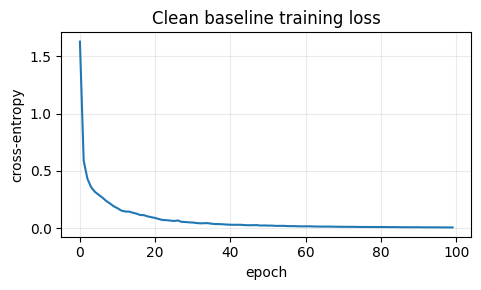

In [10]:
seed_everything(SEED)
clean_head, clean_losses = train_linear_head(
    clean_train_features, feature_dim=feature_dim, num_classes=len(class_names),
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
    weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED,
)
clean_eval = evaluate_head(clean_head, test_features, DEVICE)
print(f"clean baseline test accuracy: {clean_eval['accuracy']:.4f}")

plt.figure(figsize=(5, 3))
plt.plot(clean_losses)
plt.title("Clean baseline training loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "clean_training_loss.png", dpi=150)
plt.show()


## Showcase: one detailed poison

Base rank 0, target rank 0 - target/base/poison images plus the optimization curves.


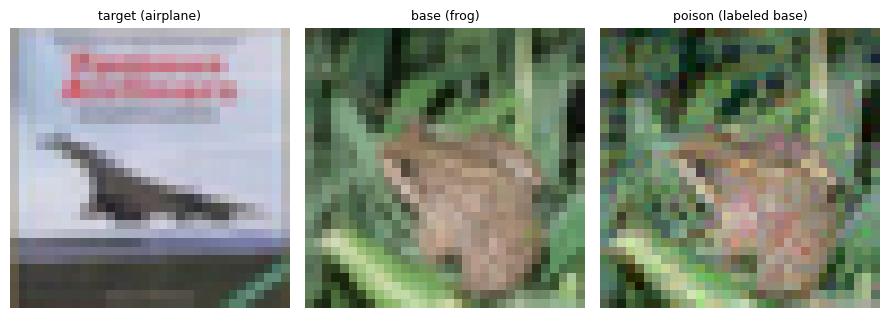

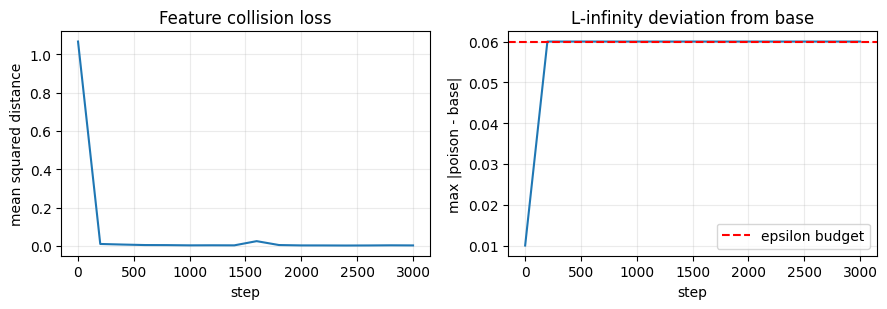

In [11]:
# Sampled from the TEST set, like the paper ("we select both target and base
# instances from the test set", Section 3.1) -- not from train_source, which
# would risk this exact image already sitting inside clean_train below.
base0 = select_ranked_sample(test_source, BASE_CLASS, BASE_RANK)
target0 = select_ranked_sample(test_source, TARGET_CLASS, 0)

showcase_poison, showcase_history = craft_feature_collision(
    extractor,
    base0["image"].unsqueeze(0).to(DEVICE),
    target0["image"].unsqueeze(0).to(DEVICE),
    steps=ATTACK_STEPS, learning_rate=ATTACK_LR, beta=ATTACK_BETA,
    epsilon=ATTACK_EPSILON, log_every=LOG_EVERY,
)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, img, title in zip(
    axes,
    [target0["image"], base0["image"], showcase_poison.squeeze(0).cpu()],
    [f"target ({class_names[TARGET_CLASS]})", f"base ({class_names[BASE_CLASS]})", "poison (labeled base)"],
):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots" / "showcase_images.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
steps = [r["step"] for r in showcase_history]
axes[0].plot(steps, [r["feature_loss"] for r in showcase_history])
axes[0].set(title="Feature collision loss", xlabel="step", ylabel="mean squared distance")
axes[1].plot(steps, [r["linf"] for r in showcase_history])
axes[1].axhline(ATTACK_EPSILON, color="r", linestyle="--", label="epsilon budget")
axes[1].set(title="L-infinity deviation from base", xlabel="step", ylabel="max |poison - base|")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots" / "showcase_optimization.png", dpi=150)
plt.show()

from torchvision.transforms.functional import to_pil_image
to_pil_image(showcase_poison.squeeze(0).cpu().clamp(0, 1)).save(OUTPUT_DIR / "poisons" / "showcase_poison.png")
to_pil_image(base0["image"].clamp(0, 1)).save(OUTPUT_DIR / "poisons" / "showcase_base.png")
to_pil_image(target0["image"].clamp(0, 1)).save(OUTPUT_DIR / "poisons" / "showcase_target.png")


In [12]:
poisoned_train_showcase = SimpleTensorDataset(
    torch.cat([clean_train.images, showcase_poison.cpu()], dim=0),
    torch.cat([clean_train.labels, torch.tensor([BASE_CLASS])], dim=0),
)
showcase_poison_feature = extract_features(
    extractor, SimpleTensorDataset(showcase_poison.cpu(), torch.tensor([BASE_CLASS])),
    DEVICE, 1, 0,
).tensors[0][0]
poisoned_train_features_showcase = TorchTensorDataset(
    torch.cat([clean_train_features.tensors[0], showcase_poison_feature.unsqueeze(0)], dim=0),
    torch.cat([clean_train_features.tensors[1], torch.tensor([BASE_CLASS])], dim=0),
)

seed_everything(SEED)
showcase_poisoned_head, _ = train_linear_head(
    poisoned_train_features_showcase, feature_dim=feature_dim, num_classes=len(class_names),
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
    weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED,
)
showcase_poisoned_eval = evaluate_head(showcase_poisoned_head, test_features, DEVICE)

target0_feature = extract_features(
    extractor, SimpleTensorDataset(target0["image"].unsqueeze(0), torch.tensor([TARGET_CLASS])),
    DEVICE, 1, 0,
).tensors[0][0]
clean_pred, clean_probs = predict_from_feature(clean_head, target0_feature, DEVICE)
poisoned_pred, poisoned_probs = predict_from_feature(showcase_poisoned_head, target0_feature, DEVICE)

print(f"clean model predicts target as:    {class_names[clean_pred]} (p={clean_probs[clean_pred]:.3f})")
print(f"poisoned model predicts target as: {class_names[poisoned_pred]} (p={poisoned_probs[poisoned_pred]:.3f})")
print(f"attack success: {clean_pred == TARGET_CLASS and poisoned_pred == BASE_CLASS}")
print(f"clean test accuracy: {clean_eval['accuracy']:.4f} -> poisoned test accuracy: {showcase_poisoned_eval['accuracy']:.4f}")


clean model predicts target as:    bird (p=0.876)
poisoned model predicts target as: frog (p=0.898)
attack success: False
clean test accuracy: 0.8118 -> poisoned test accuracy: 0.8102


## Full experiment: success rate over many targets

One fixed base, `NUM_TRIALS` targets, poisons crafted jointly for speed. Each trial gets its own freshly retrained linear head and is scored independently.


Crafting 50 poisons jointly (3000 steps)...
done in 475.6s


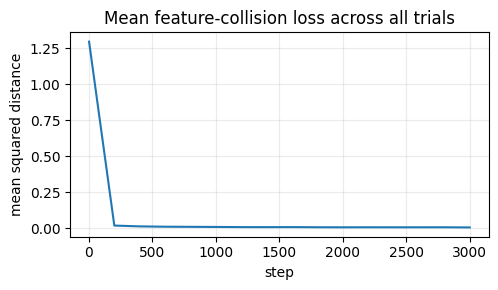

In [13]:
# Seeded-random targets, not the first NUM_TRIALS in dataset order (same
# rationale as balanced_subset above): reproducible via SEED, but not an
# arbitrary fixed slice of whatever order CIFAR-10 happens to be stored in.
targets = select_shuffled_ranks(test_source, TARGET_CLASS, NUM_TRIALS, seed=SEED)
base_repeated = base0["image"].unsqueeze(0).repeat(NUM_TRIALS, 1, 1, 1).to(DEVICE)
targets_batch = torch.stack([t["image"] for t in targets]).to(DEVICE)

print(f"Crafting {NUM_TRIALS} poisons jointly ({ATTACK_STEPS} steps)...")
t0 = time.time()
poisons_batch, batch_history, final_distances = craft_feature_collision_batch(
    extractor, base_repeated, targets_batch,
    steps=ATTACK_STEPS, learning_rate=ATTACK_LR, beta=ATTACK_BETA,
    epsilon=ATTACK_EPSILON, log_every=LOG_EVERY,
)
print(f"done in {time.time() - t0:.1f}s")

plt.figure(figsize=(5, 3))
plt.plot([r["step"] for r in batch_history], [r["feature_loss"] for r in batch_history])
plt.title("Mean feature-collision loss across all trials")
plt.xlabel("step"); plt.ylabel("mean squared distance"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "batch_optimization.png", dpi=150)
plt.show()


In [14]:
poison_features_batch = extract_features(
    extractor, SimpleTensorDataset(poisons_batch.cpu(), torch.full((NUM_TRIALS,), BASE_CLASS)),
    DEVICE, FEATURE_BATCH_SIZE, 0,
).tensors[0]

target_images_stacked = torch.stack([t["image"] for t in targets])
target_features_batch = extract_features(
    extractor, SimpleTensorDataset(target_images_stacked, torch.full((NUM_TRIALS,), TARGET_CLASS)),
    DEVICE, FEATURE_BATCH_SIZE, 0,
).tensors[0]

results = []
for trial in range(NUM_TRIALS):
    poison_feature = poison_features_batch[trial]
    poisoned_features = TorchTensorDataset(
        torch.cat([clean_train_features.tensors[0], poison_feature.unsqueeze(0)], dim=0),
        torch.cat([clean_train_features.tensors[1], torch.tensor([BASE_CLASS])], dim=0),
    )

    # Matched pair: clean and poisoned heads trained from the SAME seed, so any
    # difference between them is attributable to the one extra poison point,
    # not to a different init/shuffle landing on a different zero-loss
    # solution (the fit is underdetermined, so that alone can move a
    # prediction). The shared `clean_head`/`clean_eval` above are the
    # single-seed showcase baseline only -- not used for the per-trial numbers.
    seed_everything(SEED + trial)
    trial_clean_head, _ = train_linear_head(
        clean_train_features, feature_dim=feature_dim, num_classes=len(class_names),
        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
        weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED + trial,
    )
    seed_everything(SEED + trial)
    poisoned_head, _ = train_linear_head(
        poisoned_features, feature_dim=feature_dim, num_classes=len(class_names),
        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
        weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED + trial,
    )
    trial_clean_eval = evaluate_head(trial_clean_head, test_features, DEVICE)
    poisoned_eval = evaluate_head(poisoned_head, test_features, DEVICE)
    # Training accuracy: how well each head fits the data it was actually
    # trained on -- the paper's Appendix D claim is that this reaches ~100%
    # (near-zero training loss) precisely because the fit is underdetermined,
    # which is the mechanism this whole notebook leans on.
    clean_train_eval = evaluate_head(trial_clean_head, clean_train_features, DEVICE)
    poisoned_train_eval = evaluate_head(poisoned_head, poisoned_features, DEVICE)
    # Poison prediction: does the poisoned head actually classify the poison
    # image itself as the base class it was labeled with? If not, the fit
    # didn't take, independent of whether the target flipped.
    poison_pred, poison_probs = predict_from_feature(poisoned_head, poison_feature, DEVICE)

    clean_pred, clean_probs = predict_from_feature(trial_clean_head, target_features_batch[trial], DEVICE)
    poisoned_pred, poisoned_probs = predict_from_feature(poisoned_head, target_features_batch[trial], DEVICE)
    success = bool(clean_pred == TARGET_CLASS and poisoned_pred == BASE_CLASS)
    poison_linf = float((poisons_batch[trial] - base_repeated[trial]).abs().max().cpu())

    results.append({
        "trial": trial,
        "target_index": targets[trial]["index"],
        "clean_prediction": clean_pred,
        "poisoned_prediction": poisoned_pred,
        "poisoned_confidence_in_base": float(poisoned_probs[BASE_CLASS]),
        "poison_prediction": poison_pred,
        "poison_prediction_correct": bool(poison_pred == BASE_CLASS),
        "final_feature_distance": float(final_distances[trial]),
        "success": success,
        "clean_test_accuracy": trial_clean_eval["accuracy"],
        "poisoned_test_accuracy": poisoned_eval["accuracy"],
        "clean_train_accuracy": clean_train_eval["accuracy"],
        "poisoned_train_accuracy": poisoned_train_eval["accuracy"],
        "poison_linf": poison_linf,
    })
    print(f"trial {trial:02d}: clean={class_names[clean_pred]:>10s} poisoned={class_names[poisoned_pred]:>10s} "
          f"poison_pred={class_names[poison_pred]:>10s} success={success} "
          f"train_acc={poisoned_train_eval['accuracy']:.3f} "
          f"clean_acc={trial_clean_eval['accuracy']:.4f} poisoned_acc={poisoned_eval['accuracy']:.4f}")


trial 00: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8118 poisoned_acc=0.8110
trial 01: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8140 poisoned_acc=0.8134
trial 02: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8109 poisoned_acc=0.8126
trial 03: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8124 poisoned_acc=0.8120
trial 04: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8125 poisoned_acc=0.8133
trial 05: clean=  airplane poisoned=      frog poison_pred=      frog success=True train_acc=1.000 clean_acc=0.8130 poisoned_acc=0.8099
trial 06: clean=     horse poisoned=      frog poison_pred=      frog success=False train_acc=1.000 clean_acc=0.8109 poisoned_acc=0.8125
trial 07: clean=  airplane poisoned=      frog 

## Aggregate metrics and save `metrics.json`

In [15]:
raw_successes = sum(r["success"] for r in results)
raw_success_rate = raw_successes / len(results)

# An attack can't succeed on a target the clean model was already wrong about
# (see the Interpreting-results cell) -- report the rate among eligible
# targets separately from the raw, all-trials figure.
eligible = [r for r in results if r["clean_prediction"] == TARGET_CLASS]
eligible_successes = sum(r["success"] for r in eligible)
conditional_success_rate = eligible_successes / len(eligible) if eligible else float("nan")

mean_clean_acc = sum(r["clean_test_accuracy"] for r in results) / len(results)
mean_poisoned_acc = sum(r["poisoned_test_accuracy"] for r in results) / len(results)
mean_accuracy_delta = sum(r["poisoned_test_accuracy"] - r["clean_test_accuracy"] for r in results) / len(results)
mean_confidence_on_success = (
    sum(r["poisoned_confidence_in_base"] for r in results if r["success"]) / max(1, raw_successes)
)
mean_clean_train_acc = sum(r["clean_train_accuracy"] for r in results) / len(results)
mean_poisoned_train_acc = sum(r["poisoned_train_accuracy"] for r in results) / len(results)
poison_prediction_rate = sum(r["poison_prediction_correct"] for r in results) / len(results)
linf_values = [r["poison_linf"] for r in results]

summary = {
    "num_trials": NUM_TRIALS,
    "raw_successes": raw_successes,
    "raw_success_rate": raw_success_rate,
    "eligible_trials": len(eligible),
    "eligible_successes": eligible_successes,
    "conditional_success_rate": conditional_success_rate,
    "mean_clean_test_accuracy": mean_clean_acc,
    "mean_poisoned_test_accuracy": mean_poisoned_acc,
    "mean_accuracy_delta": mean_accuracy_delta,
    "mean_misclassification_confidence_on_success": mean_confidence_on_success,
    "mean_clean_train_accuracy": mean_clean_train_acc,
    "mean_poisoned_train_accuracy": mean_poisoned_train_acc,
    "poison_prediction_correct_rate": poison_prediction_rate,
    "poison_linf": {
        "mean": sum(linf_values) / len(linf_values),
        "min": min(linf_values),
        "max": max(linf_values),
        "budget": ATTACK_EPSILON,
    },
    "showcase_clean_baseline_accuracy": clean_eval["accuracy"],
    "target_class": class_names[TARGET_CLASS],
    "base_class": class_names[BASE_CLASS],
    "config": {
        "seed": SEED, "attack_steps": ATTACK_STEPS, "attack_lr": ATTACK_LR,
        "beta": ATTACK_BETA, "epsilon": ATTACK_EPSILON,
        "train_samples_per_class": TRAIN_SAMPLES_PER_CLASS,
        "test_samples_per_class": TEST_SAMPLES_PER_CLASS,
        "epochs": EPOCHS, "head_lr": HEAD_LR,
    },
    "trials": results,
}
with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Raw success rate:         {raw_success_rate:.1%} ({raw_successes}/{len(results)})")
print(f"Conditional success rate: {conditional_success_rate:.1%} ({eligible_successes}/{len(eligible)}) "
      f"[only targets the clean model classified correctly]")
print(f"Mean clean accuracy: {mean_clean_acc:.4f}, mean poisoned accuracy: {mean_poisoned_acc:.4f} "
      f"(mean per-trial delta {mean_accuracy_delta:+.4f})")
print(f"Mean misclassification confidence on successful attacks: {mean_confidence_on_success:.3f}")
print(f"Mean training accuracy: clean={mean_clean_train_acc:.4f}, poisoned={mean_poisoned_train_acc:.4f}")
print(f"Poison correctly classified as {class_names[BASE_CLASS]!r} in {poison_prediction_rate:.1%} of trials")
print(f"Poison L-infinity: mean={sum(linf_values)/len(linf_values):.4f}, "
      f"max={max(linf_values):.4f} (budget={ATTACK_EPSILON})")


Raw success rate:         90.0% (45/50)
Conditional success rate: 100.0% (45/45) [only targets the clean model classified correctly]
Mean clean accuracy: 0.8125, mean poisoned accuracy: 0.8117 (mean per-trial delta -0.0008)
Mean misclassification confidence on successful attacks: 0.962
Mean training accuracy: clean=1.0000, poisoned=1.0000
Poison correctly classified as 'frog' in 100.0% of trials
Poison L-infinity: mean=0.0600, max=0.0600 (budget=0.06)


## Plots: per-trial outcomes and confidence histogram

Same statistics as the paper's Fig. 5a (per-trial outcome) and Fig. 1b (confidence histogram).


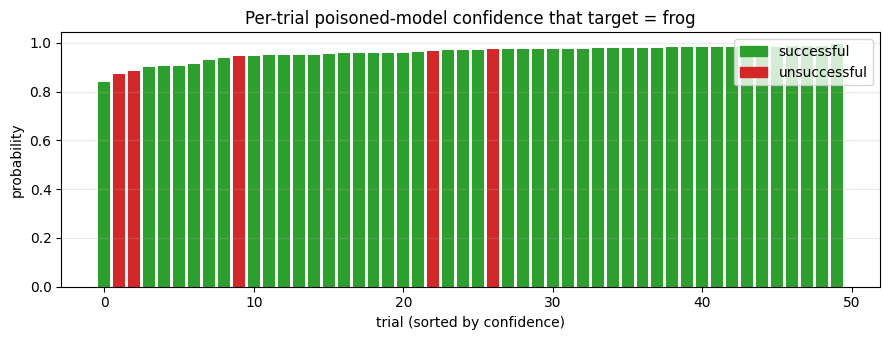

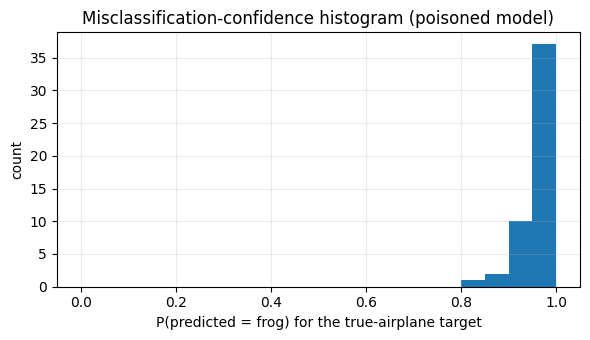

In [16]:
ordered = sorted(results, key=lambda r: r["poisoned_confidence_in_base"])
colors = ["tab:green" if r["success"] else "tab:red" for r in ordered]
values = [r["poisoned_confidence_in_base"] for r in ordered]

plt.figure(figsize=(9, 3.5))
plt.bar(range(len(ordered)), values, color=colors)
plt.title(f"Per-trial poisoned-model confidence that target = {class_names[BASE_CLASS]}")
plt.xlabel("trial (sorted by confidence)"); plt.ylabel("probability")
plt.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="tab:green", label="successful"),
    plt.Rectangle((0, 0), 1, 1, color="tab:red", label="unsuccessful"),
])
plt.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "per_trial_outcomes.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 3.5))
plt.hist([r["poisoned_confidence_in_base"] for r in results], bins=20, range=(0, 1))
plt.title("Misclassification-confidence histogram (poisoned model)")
plt.xlabel(f"P(predicted = {class_names[BASE_CLASS]}) for the true-{class_names[TARGET_CLASS]} target")
plt.ylabel("count"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "confidence_histogram.png", dpi=150)
plt.show()


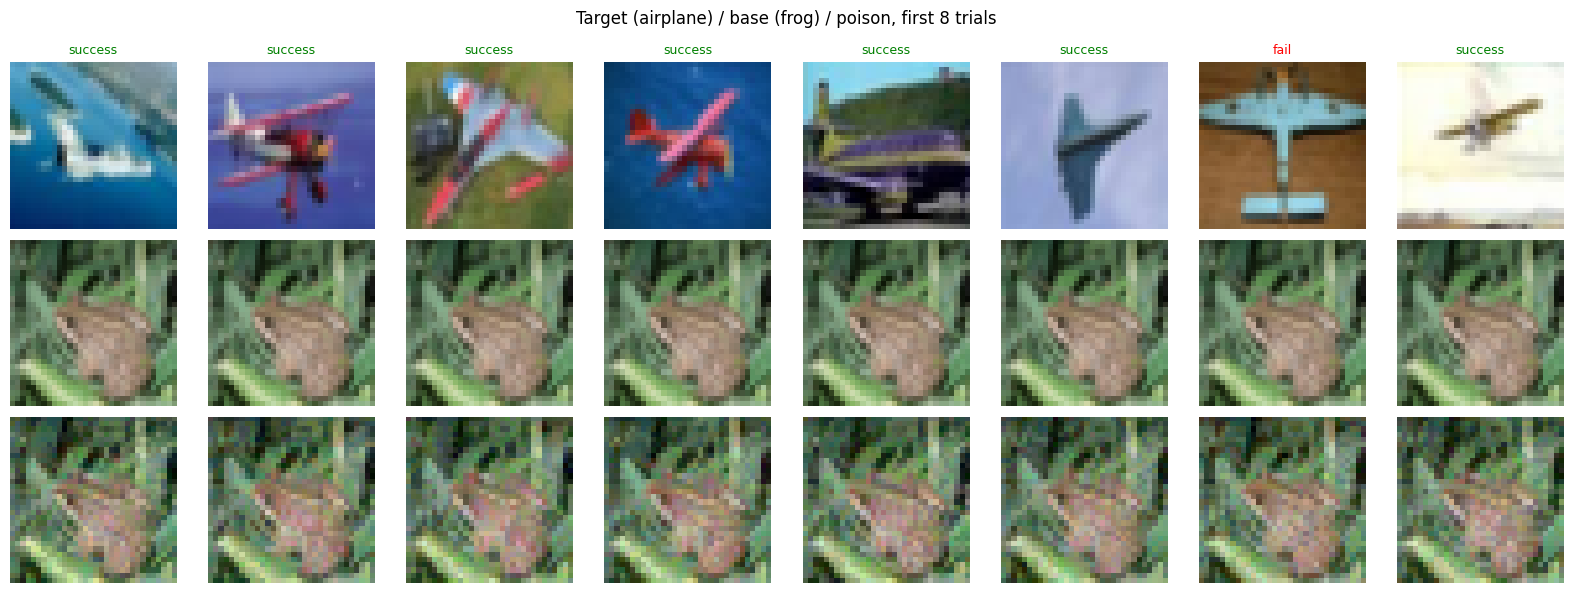

Saved artifacts to /kaggle/working/artifacts


In [17]:
from torchvision.transforms.functional import to_pil_image

num_show = min(8, NUM_TRIALS)
fig, axes = plt.subplots(3, num_show, figsize=(2 * num_show, 6))
for i in range(num_show):
    axes[0, i].imshow(targets[i]["image"].permute(1, 2, 0).numpy())
    axes[0, i].set_title("success" if results[i]["success"] else "fail",
                          color="green" if results[i]["success"] else "red", fontsize=9)
    axes[1, i].imshow(base0["image"].permute(1, 2, 0).numpy())
    axes[2, i].imshow(poisons_batch[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    for row in range(3):
        axes[row, i].axis("off")
axes[0, 0].set_ylabel("target"); axes[1, 0].set_ylabel("base"); axes[2, 0].set_ylabel("poison")
fig.suptitle(f"Target ({class_names[TARGET_CLASS]}) / base ({class_names[BASE_CLASS]}) / poison, first {num_show} trials")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots" / "poison_grid.png", dpi=150)
plt.show()

for i in range(min(10, NUM_TRIALS)):
    to_pil_image(poisons_batch[i].cpu().clamp(0, 1)).save(OUTPUT_DIR / "poisons" / f"poison_{i:02d}.png")

torch.save(clean_head.state_dict(), OUTPUT_DIR / "clean_head.pt")
print("Saved artifacts to", OUTPUT_DIR)


## Interpreting the results

- **Raw vs. conditional success rate**: raw divides by all `NUM_TRIALS`; an
  attack can't succeed on a target the clean model already misclassified
  before any poisoning, so conditional divides only by the eligible (clean
  model correct) trials -- report both, conditional is the more meaningful
  one. Treat these numbers as evidence the attack mechanism works on this
  setup, not as a figure to line up against the paper's InceptionV3
  dog-vs-fish result: different classes, extractor, dataset resolution, and
  task difficulty make a direct percentage comparison misleading either way,
  even where the numbers happen to coincide.
- **Accuracy delta**: each trial's delta comes from a clean/poisoned head pair
  trained with the *same* seed, isolating the poison's effect from ordinary
  training variance. The paper's claim is that this stays near zero even as a
  specific target is reliably flipped -- check the sign and size here.
- **Confidence histogram**: paper Fig. 1b shows poisoned-model confidence
  clustering near 1.0 for successful attacks. Compare the green bars/right
  tail of the histogram above to that figure.
- **L-infinity**: reported per poison against the `ATTACK_EPSILON` budget --
  shows how much of the perturbation budget the optimizer actually used.

If success rate is lower than desired, the first knobs to try (in order of
expected impact) are: increasing `ATTACK_STEPS`, choosing a more separable
`TARGET_CLASS`/`BASE_CLASS` pair, or picking a `BASE_RANK` closer to the
target class in feature space (the paper's Appendix E: outliers near the
decision boundary are easier to flip). The optional section below tests
`ATTACK_EPSILON` directly.

## Optional: epsilon sensitivity

Reruns a smaller version of the experiment (`NUM_TRIALS_EPS` targets, reusing
the same base and targets already selected above) at a few different
`ATTACK_EPSILON` values, including the paper's own L-infinity bound for this
exact transfer-learning one-shot-kill scenario: `epsilon = 2/255` (Appendix C
-- they report their one-shot-kill attack keeps its success rate under this
tighter, L-infinity-bounded variant of the objective; this is a different
experiment from the opacity/watermarking knob in Fig. 5b, which is specific to
the end-to-end scenario, out of this notebook's scope). Adds roughly 10-15
minutes; skip this section if you only need the headline result above.


--- epsilon = 0.00784313725490196 ---
  conditional success rate: 0.0% (0/14), mean L-inf=0.0078, train_acc=1.000, poison correctly classified: 15/15
--- epsilon = 0.03 ---
  conditional success rate: 85.7% (12/14), mean L-inf=0.0300, train_acc=1.000, poison correctly classified: 15/15
--- epsilon = 0.06 ---
  conditional success rate: 100.0% (14/14), mean L-inf=0.0600, train_acc=1.000, poison correctly classified: 15/15
--- epsilon = 0.12 ---
  conditional success rate: 100.0% (14/14), mean L-inf=0.1200, train_acc=1.000, poison correctly classified: 15/15


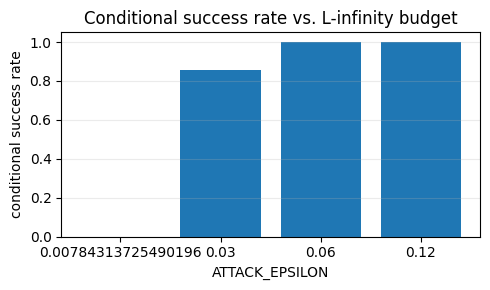

In [18]:
EPSILON_SWEEP = [2 / 255, 0.03, 0.06, 0.12]  # 2/255 is the paper's own Appendix C bound
NUM_TRIALS_EPS = 15  # a subset of the NUM_TRIALS targets already selected above
assert NUM_TRIALS_EPS <= NUM_TRIALS

eps_results = []
for eps in EPSILON_SWEEP:
    print(f"--- epsilon = {eps} ---")
    sub_base = base_repeated[:NUM_TRIALS_EPS]
    sub_targets_batch = targets_batch[:NUM_TRIALS_EPS]
    poisons_eps, _, _ = craft_feature_collision_batch(
        extractor, sub_base, sub_targets_batch,
        steps=ATTACK_STEPS, learning_rate=ATTACK_LR, beta=ATTACK_BETA,
        epsilon=eps, log_every=LOG_EVERY,
    )
    poison_features_eps = extract_features(
        extractor, SimpleTensorDataset(poisons_eps.cpu(), torch.full((NUM_TRIALS_EPS,), BASE_CLASS)),
        DEVICE, FEATURE_BATCH_SIZE, 0,
    ).tensors[0]

    successes, eligible_count, linf_vals = 0, 0, []
    train_accs, poison_hits = [], 0
    for trial in range(NUM_TRIALS_EPS):
        poisoned_features = TorchTensorDataset(
            torch.cat([clean_train_features.tensors[0], poison_features_eps[trial].unsqueeze(0)], dim=0),
            torch.cat([clean_train_features.tensors[1], torch.tensor([BASE_CLASS])], dim=0),
        )
        seed_everything(SEED + trial)
        trial_clean_head, _ = train_linear_head(
            clean_train_features, feature_dim=feature_dim, num_classes=len(class_names),
            epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
            weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED + trial,
        )
        seed_everything(SEED + trial)
        poisoned_head, _ = train_linear_head(
            poisoned_features, feature_dim=feature_dim, num_classes=len(class_names),
            epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=HEAD_LR,
            weight_decay=WEIGHT_DECAY, device=DEVICE, seed=SEED + trial,
        )
        poisoned_train_eval = evaluate_head(poisoned_head, poisoned_features, DEVICE)
        poison_pred, _ = predict_from_feature(poisoned_head, poison_features_eps[trial], DEVICE)
        clean_pred, _ = predict_from_feature(trial_clean_head, target_features_batch[trial], DEVICE)
        poisoned_pred, _ = predict_from_feature(poisoned_head, target_features_batch[trial], DEVICE)
        if clean_pred == TARGET_CLASS:
            eligible_count += 1
            if poisoned_pred == BASE_CLASS:
                successes += 1
        train_accs.append(poisoned_train_eval["accuracy"])
        poison_hits += int(poison_pred == BASE_CLASS)
        linf_vals.append(float((poisons_eps[trial] - sub_base[trial]).abs().max().cpu()))

    conditional_rate = successes / eligible_count if eligible_count else float("nan")
    eps_results.append({
        "epsilon": eps, "eligible": eligible_count, "successes": successes,
        "conditional_success_rate": conditional_rate,
        "mean_linf": sum(linf_vals) / len(linf_vals),
        "mean_poisoned_train_accuracy": sum(train_accs) / len(train_accs),
        "poison_prediction_correct_rate": poison_hits / NUM_TRIALS_EPS,
    })
    print(f"  conditional success rate: {conditional_rate:.1%} ({successes}/{eligible_count}), "
          f"mean L-inf={sum(linf_vals) / len(linf_vals):.4f}, "
          f"train_acc={sum(train_accs) / len(train_accs):.3f}, "
          f"poison correctly classified: {poison_hits}/{NUM_TRIALS_EPS}")

with open(OUTPUT_DIR / "epsilon_sweep.json", "w") as f:
    json.dump(eps_results, f, indent=2)

plt.figure(figsize=(5, 3))
plt.bar([str(r["epsilon"]) for r in eps_results], [r["conditional_success_rate"] for r in eps_results])
plt.title("Conditional success rate vs. L-infinity budget")
plt.xlabel("ATTACK_EPSILON"); plt.ylabel("conditional success rate"); plt.ylim(0, 1.05)
plt.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "epsilon_sweep.png", dpi=150)
plt.show()
